# Tugas Mandiri
---
Tugas mandiri ini digunakan pada kegiatan Kursus Data Science yang merupakan pembekalan bagi mahasiswa Universitas Gunadarma untuk Skema Supervisor Ilmuwan Data (Data Scientist Supervisor).

In [1]:
#Elricha Nafisa Joemardi_10123362_Kelas C

# Pertemuan 4 - Semester 7
# Implementasi Clustering untuk Menemukan Pola pada Data dengan Metodologi CRISP-DM


# Deskripsi Tugas
1. Mahasiswa harus membuat Project Data Science Sederhana dengan menggunakan algoritma clustering untuk menemukan kelompok atau pola tersembunyi pada suatu dataset.
2. Project dikerjakan secara lengkap mengikuti tahapan **CRISP-DM (Cross-Industry Standard Process for Data Mining)**, mulai dari Business Understanding hingga tahap Deployment.
3. Mahasiswa bebas memilih topik atau permasalahan yang relevan, selama project memiliki tujuan clustering yang jelas dan dataset memenuhi ketentuan yang telah ditetapkan.

# Judul Project:

Implementasi K-Means Clustering untuk Segmentasi Data Penjualan Superstore

# 1. Business Understanding

Pada tahap Business Understanding, kita menentukan tujuan project dan permasalahan yang ingin diselesaikan. Pada project ini, metode K-Means Clustering digunakan untuk mengelompokkan transaksi berdasarkan karakteristik penjualan sehingga dapat ditemukan kelompok transaksi yang memiliki pola serupa. Tujuan project ini adalah mengelompokkan data transaksi penjualan berdasarkan karakteristik seperti jumlah barang, penjualan, diskon, dan keuntungan menggunakan metode K-Means Clustering. Pengelompokan dilakukan untuk menemukan pola transaksi yang memiliki karakteristik serupa tanpa menentukan kelompok terlebih dahulu.

In [6]:
# Menampilkan judul project yang akan dilakukan
print("Implementasi K-Means Clustering untuk Segmentasi Data Penjualan Superstore")

Implementasi K-Means Clustering untuk Segmentasi Data Penjualan Superstore


# 2. Data Understanding

Memahami dataset dengan melihat isi data, jumlah baris dan kolom, tipe data, statistik, missing value, serta variabel numerik.

In [7]:
# Mengimpor library yang digunakan untuk pengolahan data, visualisasi, dan proses clustering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Membaca file dataset Superstore dan menyimpannya ke dalam DataFrame
df = pd.read_csv("samplesuperstore.csv")

# Menampilkan ukuran dataset berupa jumlah baris dan kolom
print("Ukuran dataset:", df.shape)

Ukuran dataset: (10194, 21)


In [9]:
# Menampilkan lima baris pertama untuk mengetahui contoh isi dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [10]:
# Menampilkan seluruh nama kolom yang terdapat dalam dataset
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [11]:
# Menampilkan informasi tipe data dan jumlah data pada setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [12]:
# Menampilkan statistik dasar seperti jumlah data, rata-rata, nilai minimum, maksimum, dan kuartil
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


In [13]:
# Menghitung jumlah nilai kosong pada setiap kolom
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [15]:
#Menghitung jumlah baris yang memiliki data duplikat
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [16]:
# Mengidentifikasi kolom yang memiliki tipe data numerik untuk menentukan kandidat variabel clustering
numeric_columns = df.select_dtypes(include=np.number).columns

# Menampilkan daftar variabel numerik
print("Variabel numerik:")
print(numeric_columns.tolist())

Variabel numerik:
['Row ID', 'Sales', 'Quantity', 'Discount', 'Profit']


Berdasarkan tahap Data Understanding, dataset telah diperiksa dari sisi ukuran data, struktur kolom, tipe data, nilai kosong, dan data duplikat. Hasil pemeriksaan menunjukkan bahwa dataset memiliki karakteristik yang sesuai untuk digunakan dalam proses clustering.

# 3. Data Preparation

Pada tahap Data Preparation, pilih variabel yang relevan untuk clustering, membersihkan data kosong, dan melakukan standardisasi agar setiap variabel memiliki skala yang sebanding.

Untuk Superstore, kandidat variabel yang mudah digunakan adalah:

Sales, 
Quantity, 
Discount, dan
Profit

Keempatnya menggambarkan karakteristik transaksi dan cocok untuk membentuk kelompok transaksi.

In [17]:
# Menentukan variabel numerik yang digunakan sebagai fitur dalam proses clustering
features = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

# Membuat DataFrame baru yang hanya berisi variabel untuk clustering
data_cluster = df[features].copy()

# Menampilkan lima data pertama dari data clustering
data_cluster.head()

,Sales,Quantity,Discount,Profit
0,16.448,2,0.2,5.5512
1,3.540,2,0.8,-5.4870
2,11.784,3,0.2,4.2717
3,272.736,3,0.2,-64.7748
4,19.536,3,0.2,4.8840


In [18]:
# Mengecek jumlah nilai kosong pada variabel yang digunakan untuk clustering
print(data_cluster.isnull().sum())

Sales       0
Quantity    0
Discount    0
Profit      0
dtype: int64


In [19]:
# Menghapus baris yang memiliki nilai kosong agar data dapat digunakan dalam proses clustering
data_cluster = data_cluster.dropna()

# Menampilkan jumlah data setelah proses cleaning
print("Jumlah data setelah cleaning:", len(data_cluster))

Jumlah data setelah cleaning: 10194


In [20]:
# Mengimpor StandardScaler untuk menyamakan skala setiap variabel clustering
from sklearn.preprocessing import StandardScaler

# Membuat objek StandardScaler
scaler = StandardScaler()

# Melakukan standardisasi terhadap variabel yang digunakan untuk clustering
X_scaled = scaler.fit_transform(data_cluster)

# Menampilkan ukuran data setelah standardisasi
print("Ukuran data:", X_scaled.shape)

Ukuran data: (10194, 4)


Berdasarkan tahap Data Preparation, data telah dipilih menggunakan variabel yang relevan untuk proses clustering, kemudian dilakukan pengecekan dan penanganan nilai kosong. Selanjutnya, data distandardisasi menggunakan StandardScaler agar setiap variabel memiliki skala yang sebanding sebelum digunakan dalam proses K-Means.

# 4. Modeling

Pada tahap Modeling, kita menggunakan algoritma K-Means untuk membentuk kelompok transaksi. Sebelum menentukan model akhir, kita menggunakan Elbow Method untuk membantu menentukan jumlah cluster.

In [22]:
# Mengimpor algoritma K-Means yang digunakan untuk melakukan clustering
from sklearn.cluster import KMeans

In [23]:
# Membuat list untuk menyimpan nilai inertia dari setiap jumlah cluster
inertia = []

# Mencoba jumlah cluster dari 2 sampai 8
for k in range(2, 9):

    # Membuat model K-Means dengan jumlah cluster sesuai nilai k
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Melatih model menggunakan data yang telah distandardisasi
    kmeans.fit(X_scaled)

    # Menyimpan nilai inertia dari model
    inertia.append(kmeans.inertia_)

In [24]:
# Membuat list untuk menyimpan nilai inertia dari setiap jumlah cluster
inertia = []

# Mencoba jumlah cluster dari 2 sampai 8
for k in range(2, 9):

    # Membuat model K-Means dengan jumlah cluster sesuai nilai k
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Melatih model menggunakan data yang telah distandardisasi
    kmeans.fit(X_scaled)

    # Menyimpan nilai inertia dari model
    inertia.append(kmeans.inertia_)

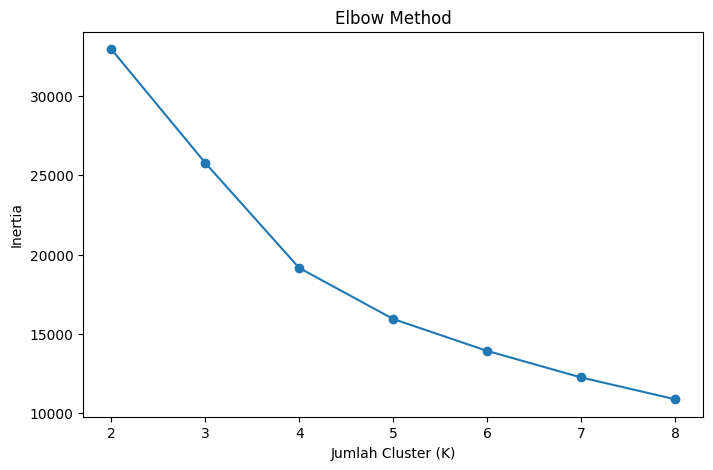

In [25]:
# Membuat grafik Elbow Method untuk membantu menentukan jumlah cluster yang sesuai
plt.figure(figsize=(8,5))

# Menampilkan hubungan antara jumlah cluster dan nilai inertia
plt.plot(
    range(2, 9),
    inertia,
    marker="o"
)

# Memberikan nama sumbu dan judul grafik
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

# Menampilkan grafik
plt.show()

Grafik Elbow Method digunakan untuk menentukan jumlah cluster yang sesuai pada algoritma K-Means dengan melihat perubahan nilai inertia pada setiap jumlah cluster. Nilai inertia akan semakin kecil ketika jumlah cluster bertambah, tetapi setelah titik tertentu penurunannya mulai melambat. Titik ketika penurunan mulai melandai disebut sebagai titik elbow dan dapat digunakan sebagai pertimbangan dalam menentukan jumlah cluster yang digunakan pada model K-Means.

In [27]:
# Membuat model K-Means dengan jumlah cluster sebanyak 3
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Melatih model dan menghasilkan label cluster untuk setiap data
cluster_labels = kmeans.fit_predict(X_scaled)

In [28]:
# Menampilkan beberapa hasil label cluster untuk memastikan proses clustering berhasil
print(cluster_labels[:10])

[1 2 1 1 1 0 1 1 1 1]


In [29]:
# Menambahkan label cluster ke dalam DataFrame hasil clustering
data_cluster["Cluster"] = cluster_labels

# Menampilkan lima data pertama beserta hasil cluster
data_cluster.head()

,Sales,Quantity,Discount,Profit,Cluster
0,16.448,2,0.2,5.5512,1
1,3.540,2,0.8,-5.4870,2
2,11.784,3,0.2,4.2717,1
3,272.736,3,0.2,-64.7748,1
4,19.536,3,0.2,4.8840,1


In [30]:
# Menghitung jumlah transaksi yang terdapat pada setiap cluster
print(data_cluster["Cluster"].value_counts().sort_index())

Cluster
0      77
1    8963
2    1154
Name: count, dtype: int64


Berdasarkan tahap Modeling, algoritma K-Means berhasil diterapkan untuk mengelompokkan data berdasarkan karakteristik yang telah dipilih. Jumlah cluster ditentukan menggunakan Elbow Method, kemudian model K-Means digunakan untuk memberikan label cluster pada setiap data.

# 5. Evaluation

Pada tahap Evaluation, kita mengevaluasi kualitas cluster menggunakan Silhouette Score dan menganalisis karakteristik masing-masing cluster.

In [39]:
# Mengimpor fungsi Silhouette Score untuk mengevaluasi kualitas hasil clustering
from sklearn.metrics import silhouette_score

# Menghitung nilai Silhouette Score berdasarkan hasil clustering
score = silhouette_score(
    X_scaled,
    cluster_labels
)

# Menampilkan nilai Silhouette Score
print("Silhouette Score:", score)

Silhouette Score: 0.5179076015712645


In [40]:
# Menghitung nilai rata-rata setiap variabel berdasarkan kelompok cluster
cluster_profile = data_cluster.groupby("Cluster").mean()

# Menampilkan karakteristik rata-rata setiap cluster
cluster_profile

,Sales,Quantity,Discount,Profit
Cluster,,,,
0,4902.535883,5.857143,0.083117,1418.317038
1,193.662411,3.761910,0.092826,34.300383
2,184.785878,3.886482,0.646092,-107.753838


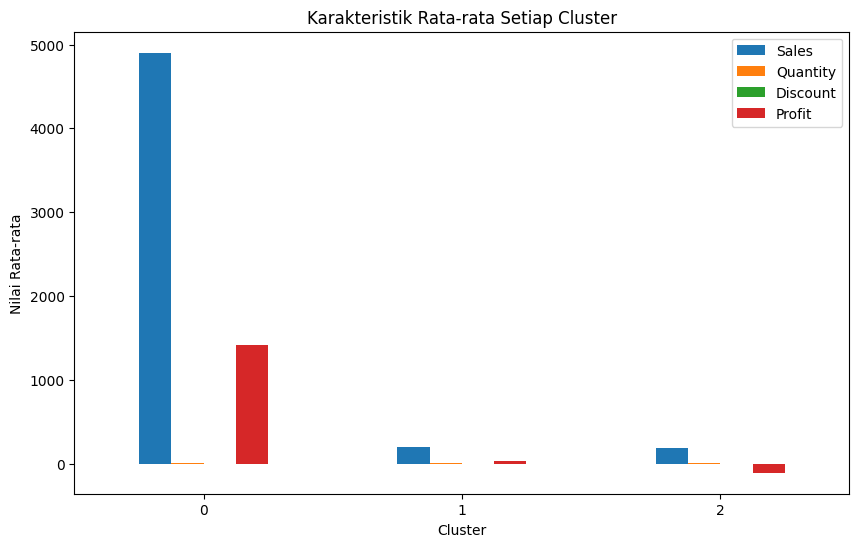

In [41]:
# Membuat diagram batang untuk membandingkan karakteristik rata-rata setiap cluster
cluster_profile.plot(
    kind="bar",
    figsize=(10,6)
)

# Memberikan judul dan nama sumbu pada grafik
plt.title("Karakteristik Rata-rata Setiap Cluster")
plt.xlabel("Cluster")
plt.ylabel("Nilai Rata-rata")
plt.xticks(rotation=0)

# Menampilkan grafik
plt.show()

Grafik menunjukkan perbandingan nilai rata-rata setiap variabel pada masing-masing cluster. Perbedaan tinggi batang menunjukkan bahwa setiap cluster memiliki karakteristik transaksi yang berbeda berdasarkan Sales, Quantity, Discount, dan Profit. Grafik ini membantu melihat variabel yang paling membedakan karakteristik antarcluster dan memahami pola dari masing-masing kelompok yang terbentuk.

Berdasarkan tahap Evaluation, hasil clustering dievaluasi menggunakan Silhouette Score dan analisis karakteristik masing-masing cluster. Profil cluster menunjukkan adanya perbedaan karakteristik antar kelompok sehingga hasil clustering dapat digunakan untuk memahami pola dan segmentasi data penjualan.

# 6. Deployment

Pada tahap Deployment, model yang sudah dibuat digunakan dalam aplikasi sederhana menggunakan Streamlit. Aplikasi memungkinkan pengguna memasukkan karakteristik transaksi dan mendapatkan hasil cluster.

In [42]:
# Mengimpor joblib untuk menyimpan model dan scaler ke dalam file
import joblib

# Menyimpan model K-Means yang telah dilatih
joblib.dump(kmeans, "kmeans_model.pkl")

# Menyimpan scaler yang digunakan dalam proses standardisasi
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Berdasarkan hasil evaluasi, clustering berhasil membentuk beberapa kelompok dengan karakteristik yang berbeda. Perbedaan nilai rata-rata pada setiap variabel menunjukkan adanya pola yang dapat digunakan untuk memahami karakteristik masing-masing cluster.

In [43]:
# Menyimpan model K-Means yang telah dilatih ke dalam file
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")

print("Model K-Means berhasil disimpan sebagai kmeans_model.pkl")

Model K-Means berhasil disimpan sebagai kmeans_model.pkl
